# Day 4c: <span style="color:red; font-size:1.1em">Exploratory Data Analyis</span> and Helper Functions

In this notebook which includes show-and-tell style examples, we will learn about the following functions that will **help immensely** with data analysis:
- The **describe()** function for descriptive statistics.
- The **box()** function for creating box plots.
- The **.hist** table method for creating histograms.
- The **density()** function for creating density plots.

In [27]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import seaborn as sns
import scipy.stats as stats
from scipy.stats import gaussian_kde

## Read in a CSV data file from the web.
skyscrapers = Table.read_table('skyscrapers.csv')
pers = Table.read_table('http://faculty.ung.edu/rsinn/personality.csv')
births = Table.read_table('https://faculty.ung.edu/rsinn/data/baby.csv')

## <span style="font-weight:bold;font-size:1.1em">Creating the Functions</span>

We as users have to define the functions listed above. The code block below does that work for us. Just execute the cell. Do not edit it at all.

In [28]:
def describe(data, var = None):
  if isinstance(data, Table):
    data = data.column(var)
  names = np.array(["Mean", "Std Dev", "Sample Size", "Min", "Q1", "Median", "Q3", "Max"])
  values = np.array([round(np.mean(data),1), round(stats.tstd(data),2), len(data) - 1, min(data), np.percentile(data, 25), np.median(data), np.percentile(data, 75), max(data)])
  tab = Table().with_columns('Names', names, 'Values', values)  ;  transposed_tab = Table().with_columns( zip(tab.column('Names'), tab.column('Values')) ).show()
  return

def describes(data, num, group):
  dat = data.column(num)  ;  group_var = data.column(group)  ;  groups = np.unique(group_var)  ;  rows = []  ;  tab = Table(['Group', 'Mean', 'Std. Dev.', 'Sample Size', 'Min', 'Q1', 'Median', 'Q3', 'Max'])
  for g in groups:
    # Filter data for the current group
    sub_dat = dat[group_var == g]  ;    rows = [g, round(np.mean(sub_dat), 1), round(stats.tstd(sub_dat), 2), len(sub_dat) - 1, min(sub_dat), np.percentile(sub_dat, 25), np.median(sub_dat), np.percentile(sub_dat, 75), max(sub_dat)]        
    tab = tab.with_row(rows)
  tab.show()
  return 

def box(data, num = None, sm = False):
  if isinstance(data, Table):
    df = data.to_df()  ;  sns.boxplot(data=df, y=num, width=0.45, showmeans=sm)  ;
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()  
  else:
    if num == True:
      sm = True  ;  num = 'Variable'
    if num == None:
      num = 'Variable'
    plots.figure(figsize=(6, 6))  ;  plots.boxplot(data, widths = 0.45, showmeans=sm)
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()
  return

def boxes(data, num, cat, sm = False):
  if not isinstance(data, Table):
    print("ERROR: First input must be table name.")
  else:
    df = data.to_df()  ;  sns.boxplot(data=data, x=cat, y=num, width=0.75, showmeans=sm)
    plots.title(f'Boxplot of {num} Grouped by {cat}')  ;  plots.show()
  return

def density(data, num = None):
  if isinstance(data, Table):
    sns.kdeplot( data = data.column(num), bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  else:
    if num == None:
      num = 'Variable'  ;  sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
    else:
      sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  return

def densities(tab, var, group_var):
  groups = tab.column(group_var) ;  unique_groups = np.unique(groups)  ;  plots.figure()
  for g in unique_groups:
    # Filter data for the current group
    mask = (groups == g)
    x = tab.column(var)[mask]   
    # Calculate KDE for the group subset
    kde = gaussian_kde(x)
    x_grid = np.linspace(x.min() - 1, x.max() + 1, 512)  ;    plots.plot(x_grid, kde(x_grid), label=str(g))   
  plots.title(f'Density Plot of {var} by {group_var}')  ;  plots.xlabel(f'{var}')  ;  plots.ylabel('Density')
  plots.legend()  ;  plots.show()
  return




## <span style="color:blue; font-weight:bold;font-size:1.1em">Example 1: November Temps</span>

We imported data tables above, but let's beging with our November daily high temperatures in Dahlonega array:

In [29]:
N = make_array(67, 65, 66, 63, 60, 62, 64, 68, 71, 69, 65, 62, 59, 58, 61,
               63, 66, 62, 59, 57, 55, 58, 60, 63, 62, 58, 56, 54, 57, 59)

### <span style="font-weight:bold;font-size:1.1em">Example 1: Descriptive Statistics</span>

We would like to know the <span style="color:red; font-weight:bold; font-size:1.1em">mean, standard deviation, sample size and the 5-number summary</span>. Instead of calculating each one and doing so one at a time, we can use the describe() function.

<center></span> <span style="color:blue; font-weight:bold; font-size:1.5em">describe()</span></center> function.

In [30]:
describe(N)

Mean,Std Dev,Sample Size,Min,Q1,Median,Q3,Max
61.6,4.26,29,54,58.25,62,64.75,71


### <span style="font-weight:bold;font-size:1.1em">Example 1: Box Plots</span>

The <span style="color:red; font-weight:bold; font-size:1.1em">box plot</span> is a visualization of the<span style="color:red; font-weight:bold; font-size:1.1em">5-number summary</span>. The function

<center></span> <span style="color:blue; font-weight:bold; font-size:1.1em">box()</span></center> will create one for us. The option
<center></span> <span style="color:blue; font-weight:bold; font-size:1.1em">show_menans = True</span></center>

will display the mean on the boxplot as a <span style="color:#C68A1C; font-weight:bold; font-size:1.1em">yellow triangle</span>.

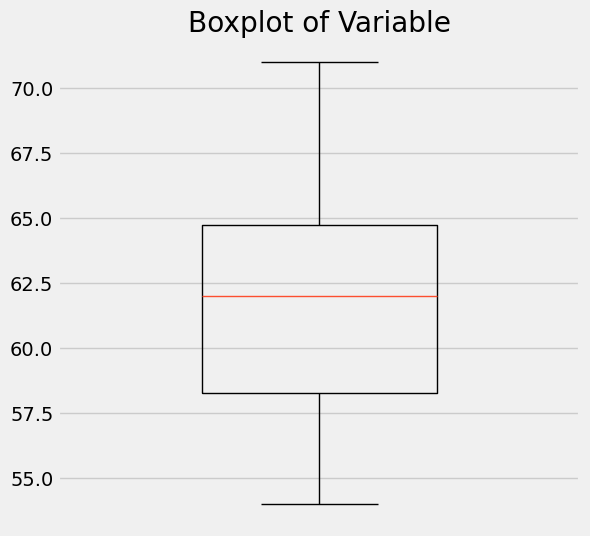

In [33]:
box(N)

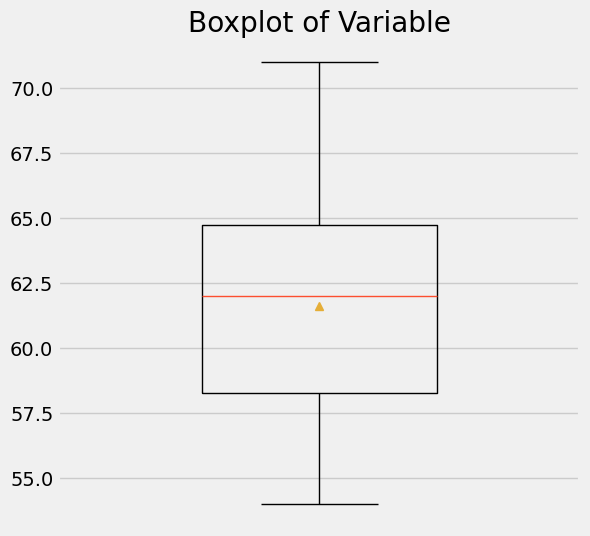

In [35]:
box(N, True)

### <span style="font-weight:bold;font-size:1.1em">Example 1: Histograms</span>

To display a <span style="color:red; font-weight:bold; font-size:1.1em">histogram</span> of the data, we wuse the <center></span> <span style="color:blue; font-weight:bold; font-size:1.5em">.hist()</span></center> table method.

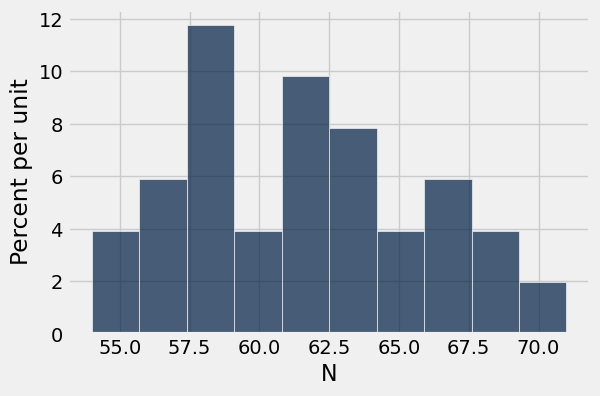

In [12]:
tab = Table().with_columns("N", N)
tab.hist('N')

### <span style="font-weight:bold;font-size:1.1em">Example 1: Density Plots</span>

To display a <span style="color:red; font-weight:bold; font-size:1.1em">density plot</span> of the data, we wuse the <center></span> <span style="color:blue; font-weight:bold; font-size:1.5em">density()</span></center>function.

We can add a <span style="color:red; font-weight:bold; font-size:1.1em">second input</span> to update the<span style="color:red; font-weight:bold; font-size:1.1em">title</span>.

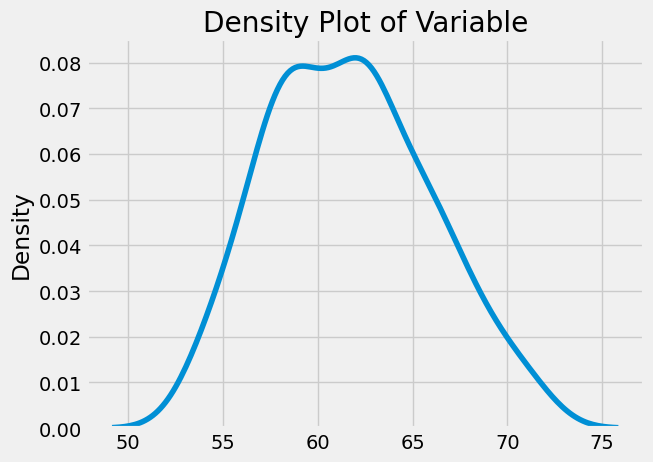

In [13]:
density(N)

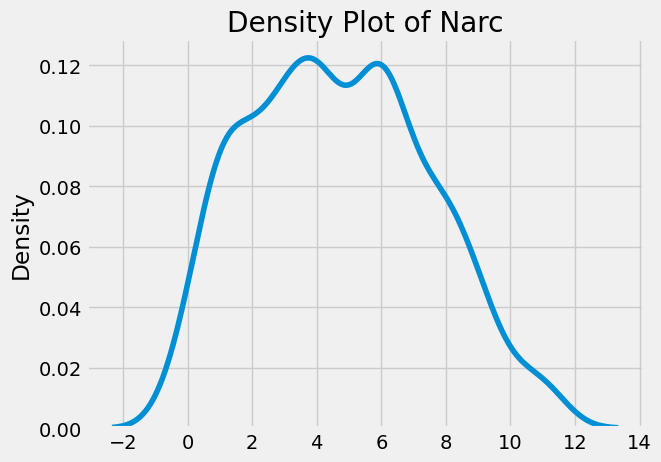

In [36]:
density(pers, "Narc")

## <span style="color:blue; font-weight:bold;font-size:1.1em">Example 2: Narcissism</span>
Create:
1. A histogram
2. Descriptive statistics
3. A boxplot
4. A density plot

for the **Narcissism** variable from the **personality** data set.

<span style="color:blue; font-weight:bold;font-size:1.1em">Also, group by the **Sex** variable to compare and contrast Narcissism between biological males and females.</span>

In [21]:
hist_narc = ...

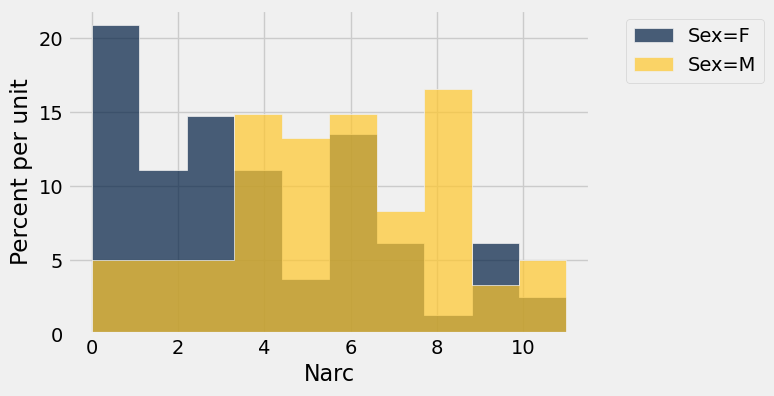

In [22]:
hist_narc_grouped = pers.hist('Narc', group = 'Sex')

In [17]:
descriptives_narc = ...

In [37]:
descriptives_narc_grouped = describes(pers,'Narc', 'Sex')

Group,Mean,Std. Dev.,Sample Size,Min,Q1,Median,Q3,Max
F,3.9,2.75,73,0,2,3,6,11
M,5.7,2.43,54,1,4,6,8,11


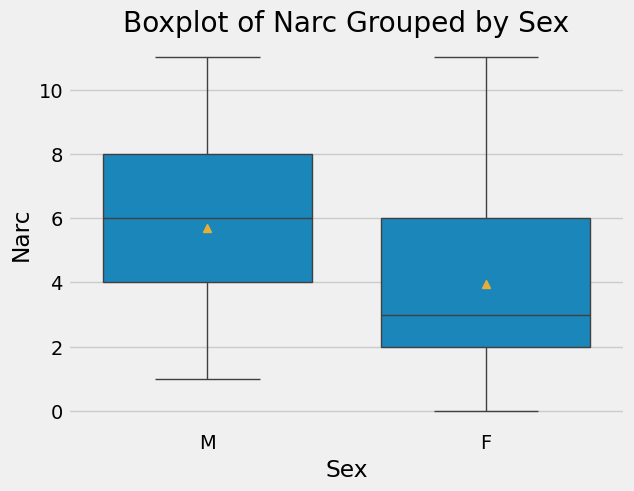

In [38]:
boxplots_narc_grouped = boxes(pers,'Narc', 'Sex', True)

<span style="color:blue; font-weight:bold;font-size:1.1em">Add a 4th input value of True to your boxplots to diplay the means.</span>

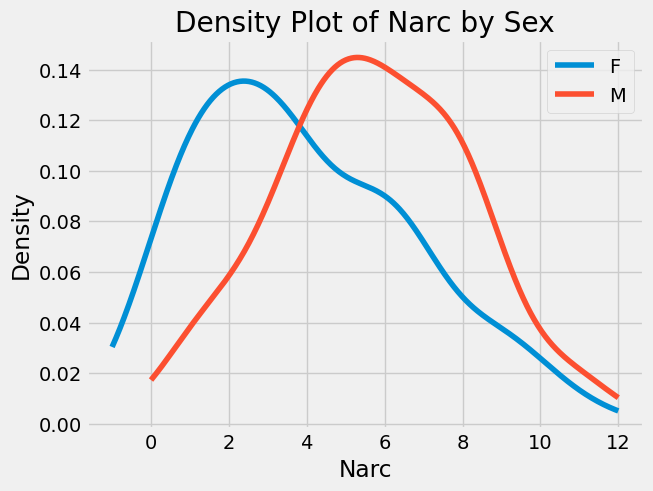

In [39]:
densities_narc_grouped = densities(pers,'Narc',"Sex")